# Normalizing flows

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

import helper_galah as galah
import helper_dl as dl

### Loading data

In [2]:
# Load the data
PATH = "../datasets"
spectra, labels, label_names, units, spectra_length, n_labels, n_samples = galah.load_galah_data(PATH)

### Hyperparameter selection

In [3]:
# Hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 20
patience = 5 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
val_fraction = 0.15
test_fraction = 0.15

### Prepare data por training

In [4]:
# Normalize the spectra
spectra_scaled = np.log(np.maximum(spectra, 0.2))

# Split data into train, validation and test
X_train, X_val, X_test, labels_train, labels_val, labels_test = galah.split_data(spectra_scaled, labels, 
                                                                                 val_fraction=val_fraction, test_fraction=test_fraction)

# Normalize the labels
y_train, y_val, y_test, scaler = galah.scale_labels(labels_train, labels_val, labels_test)

# Create the dataloaders
train_loader, val_loader, test_loader = galah.create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test,
                                                                 spectra_length=spectra_length, n_labels=n_labels, batch_size=batch_size)

### Definition of the model and the loss function

In [5]:
class GalahCNN(nn.Module):
    def __init__(self):
        super(GalahCNN, self).__init__()
        
        # Feature extraction (3 convolutional layers)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Linear regression (2 fully connected layers)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spectra_length // 8, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Avoid overfitting
            nn.Linear(256, 2*n_labels) # Output: Teff, logg, [Fe/H] AND UNCERTAINTIES
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [6]:
# Negative log-likelihood loss function for regression with uncertainty estimation
def nll_loss(preds, targets):
    # Split predictions into mean and log variance
    mean = preds[:, :n_labels]
    log_std = preds[:, n_labels:]
    
    # Calculate the negative log-likelihood loss
    std = torch.exp(log_std)
    nll = torch.mean(0.5 * (targets - mean) ** 2 / (std ** 2) + log_std)
    
    return nll

### Training the neural network

In [7]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

# Initialize the model
model = GalahCNN().to(device)
loss_fn = nll_loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Print the model summary before moving it to the device
summary(model);

Using device: xpu
Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       192
|    └─ReLU: 2-2                         --
|    └─MaxPool1d: 2-3                    --
|    └─Conv1d: 2-4                       3,616
|    └─ReLU: 2-5                         --
|    └─MaxPool1d: 2-6                    --
|    └─Conv1d: 2-7                       10,304
|    └─ReLU: 2-8                         --
|    └─MaxPool1d: 2-9                    --
├─Sequential: 1-2                        --
|    └─Flatten: 2-10                     --
|    └─Linear: 2-11                      33,554,688
|    └─ReLU: 2-12                        --
|    └─Dropout: 2-13                     --
|    └─Linear: 2-14                      1,542
Total params: 33,570,342
Trainable params: 33,570,342
Non-trainable params: 0


In [8]:
# Train the model
train_losses, val_losses = dl.train_nn(train_loader, val_loader, model, loss_fn, optimizer,
                                       num_epochs=num_epochs, patience=5, device=device)


Training GalahCNN on xpu
Epoch [1/20], Train Loss: 0.3142, Val Loss: 0.0955, Time: 14.92 seconds
Epoch [2/20], Train Loss: -0.0519, Val Loss: -0.3229, Time: 12.24 seconds
Epoch [3/20], Train Loss: -0.3595, Val Loss: -0.5709, Time: 12.26 seconds
Epoch [4/20], Train Loss: -0.5361, Val Loss: -0.7498, Time: 12.03 seconds
Epoch [5/20], Train Loss: -0.6498, Val Loss: -0.8043, Time: 11.91 seconds
Epoch [6/20], Train Loss: -0.7184, Val Loss: -0.9541, Time: 13.62 seconds
Epoch [7/20], Train Loss: -0.7683, Val Loss: -0.8571, Time: 12.94 seconds
Epoch [8/20], Train Loss: -0.7918, Val Loss: -0.9596, Time: 12.04 seconds
Epoch [9/20], Train Loss: -0.8402, Val Loss: -0.9917, Time: 12.62 seconds
Epoch [10/20], Train Loss: -0.8464, Val Loss: -1.0044, Time: 11.98 seconds
Epoch [11/20], Train Loss: -0.8780, Val Loss: -1.0583, Time: 12.61 seconds
Epoch [12/20], Train Loss: -0.8891, Val Loss: -0.8478, Time: 13.02 seconds
Epoch [13/20], Train Loss: -0.9063, Val Loss: -1.0460, Time: 12.54 seconds
Epoch [14/2

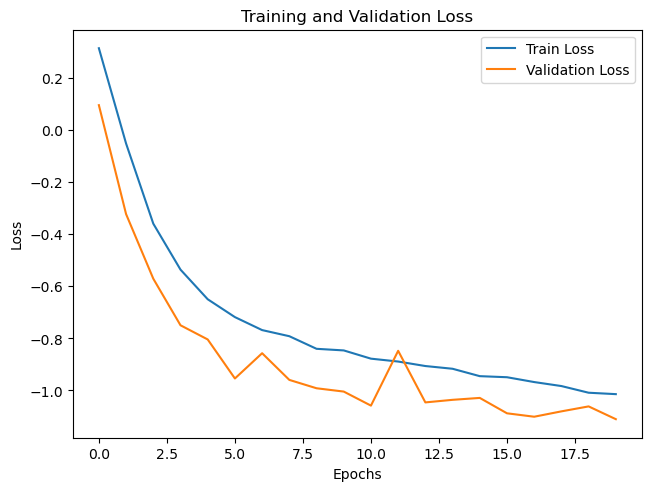

In [9]:
# Plot training/validation loss
dl.plot_losses(train_losses, val_losses)

### Evaluating the model

In [10]:
y_test_pred, test_loss = dl.test_nn(test_loader, model, loss_fn, device)
y_test_pred = y_test_pred.reshape(-1, 2, n_labels)

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Train Loss: -1.0143
Final Validation Loss: -1.1104
Final Test Loss: -1.1912


In [11]:
labels_test_pred = scaler.inverse_transform(y_test_pred[:, 0, :])
uncertainties_test = scaler.scale_ * np.exp(y_test_pred[:, 1, :])

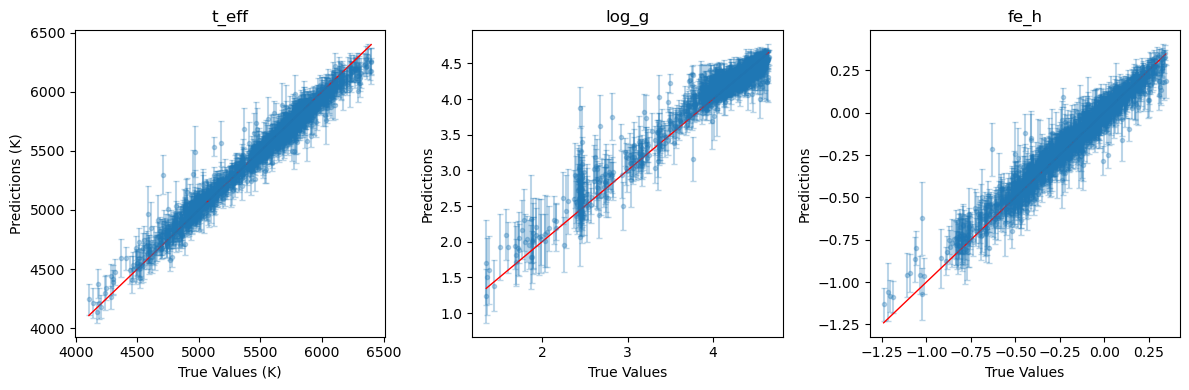

In [12]:
galah.plot_predicter_vs_true(labels_test, labels_test_pred, n_labels=n_labels, label_names=label_names, units=units, errors=uncertainties_test)

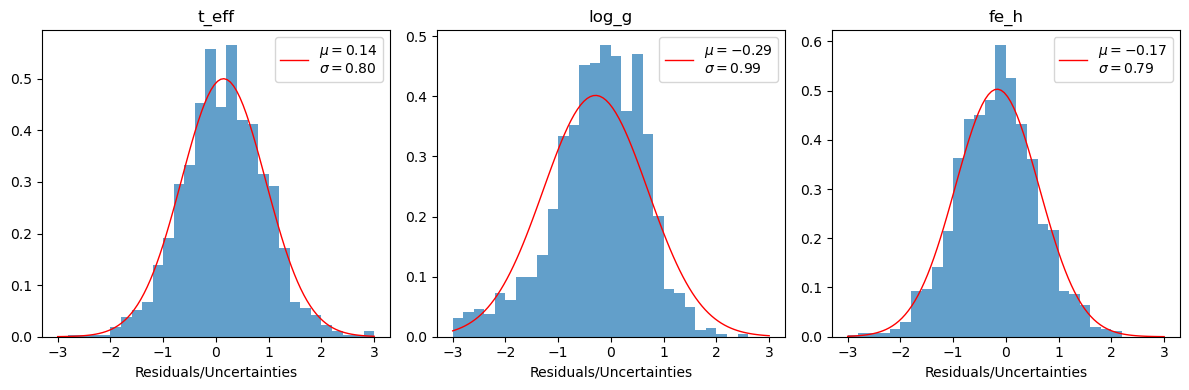

In [13]:
galah.plot_pull_distribution(labels_test, labels_test_pred, n_labels=n_labels, label_names=label_names, errors=uncertainties_test)